In [3]:
!pip install pandas scikit-learn matplotlib nltk

In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

In [6]:
df = pd.read_csv("banking_complaints.csv")

print(df.head())
print("\nDataset Shape:", df.shape)

                                           Complaint
0   My money was deducted but the transaction failed
1       I was charged twice for the same transaction
2  The ATM did not dispense cash but money was de...
3           My online banking account is not working
4  I cannot log in to the mobile banking application

Dataset Shape: (35, 1)


In [7]:
print(df.isnull().sum())

df = df.dropna()

Complaint    0
dtype: int64


In [8]:
def preprocess_text(text):
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df["Cleaned_Complaint"] = df["Complaint"].apply(preprocess_text)

print(df[["Complaint", "Cleaned_Complaint"]].head())

                                           Complaint  \
0   My money was deducted but the transaction failed   
1       I was charged twice for the same transaction   
2  The ATM did not dispense cash but money was de...   
3           My online banking account is not working   
4  I cannot log in to the mobile banking application   

                                   Cleaned_Complaint  
0   my money was deducted but the transaction failed  
1       i was charged twice for the same transaction  
2  the atm did not dispense cash but money was de...  
3           my online banking account is not working  
4  i cannot log in to the mobile banking application  


In [9]:
def categorize_complaint(text):

    text = text.lower()

    if any(word in text for word in [
        "loan", "installment", "interest"
    ]):
        return "Loan Issues"

    elif any(word in text for word in [
        "atm", "cash", "withdrawing"
    ]):
        return "ATM Issues"

    elif any(word in text for word in [
        "credit card", "card transaction"
    ]):
        return "Credit Card Issues"

    elif any(word in text for word in [
        "online banking", "mobile banking",
        "application", "app", "website",
        "log in", "password"
    ]):
        return "Online Banking Issues"

    elif any(word in text for word in [
        "account", "balance", "beneficiary",
        "personal details"
    ]):
        return "Account Management Issues"

    elif any(word in text for word in [
        "customer service", "customer support"
    ]):
        return "Customer Service Issues"

    elif any(word in text for word in [
        "transaction", "payment", "transfer",
        "deducted", "charged"
    ]):
        return "Transaction Issues"

    else:
        return "Other Issues"


df["Category"] = df["Cleaned_Complaint"].apply(
    categorize_complaint
)

print(df[["Complaint", "Category"]].head(10))

                                           Complaint  \
0   My money was deducted but the transaction failed   
1       I was charged twice for the same transaction   
2  The ATM did not dispense cash but money was de...   
3           My online banking account is not working   
4  I cannot log in to the mobile banking application   
5                The bank application keeps crashing   
6  My loan application has been rejected without ...   
7                 The loan interest rate is too high   
8      I am unable to pay my loan installment online   
9                My account was blocked unexpectedly   

                    Category  
0         Transaction Issues  
1         Transaction Issues  
2                 ATM Issues  
3      Online Banking Issues  
4      Online Banking Issues  
5      Online Banking Issues  
6                Loan Issues  
7                Loan Issues  
8                Loan Issues  
9  Account Management Issues  


In [10]:
category_count = df["Category"].value_counts()

print(category_count)

Category
Account Management Issues    10
Online Banking Issues         6
Transaction Issues            6
Loan Issues                   5
ATM Issues                    4
Credit Card Issues            2
Customer Service Issues       2
Name: count, dtype: int64


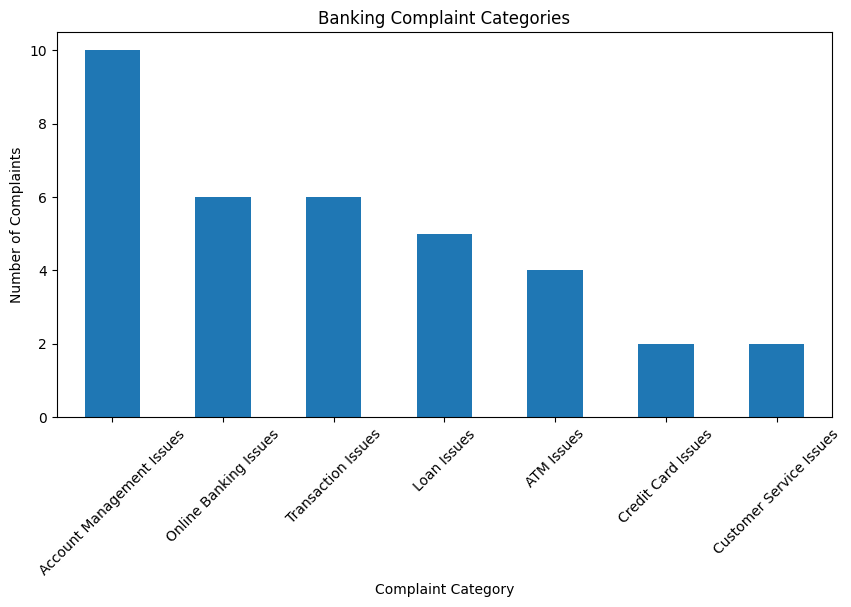

In [11]:
plt.figure(figsize=(10, 5))

category_count.plot(kind="bar")

plt.title("Banking Complaint Categories")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)

plt.show()

In [12]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(
    df["Cleaned_Complaint"]
)

word_frequency = pd.DataFrame(
    X.toarray().sum(axis=0),
    index=vectorizer.get_feature_names_out(),
    columns=["Frequency"]
)

word_frequency = word_frequency.sort_values(
    by="Frequency",
    ascending=False
)

print(word_frequency)

             Frequency
account             11
transaction          7
banking              5
bank                 5
loan                 5
online               5
money                4
charged              4
deducted             4
application          3
atm                  3
card                 3
failed               3
incorrect            3
did                  2
credit               2
mobile               2
received             2
slow                 2
transfer             2


In [13]:
top_category = category_count.idxmax()

print("Most Frequent Complaint Category:", top_category)

print(
    "Number of Complaints:",
    category_count.max()
)

Most Frequent Complaint Category: Account Management Issues
Number of Complaints: 10


In [14]:
print("\n========== BANKING COMPLAINT ANALYSIS REPORT ==========")

print("\nTotal Complaints:", len(df))

print("\nComplaint Category Distribution:")
print(category_count)

print("\nMost Frequent Complaint Category:")
print(top_category)

print("\nMost Common Banking Keywords:")
print(word_frequency.head(10))

print("\nRecommendations:")

print("1. Improve transaction monitoring systems.")
print("2. Provide faster resolution for failed transactions.")
print("3. Improve mobile and online banking application stability.")
print("4. Simplify loan application and repayment processes.")
print("5. Improve ATM maintenance and transaction reliability.")
print("6. Strengthen account security against unauthorized transactions.")
print("7. Improve customer support response time.")


========== BANKING COMPLAINT ANALYSIS REPORT ==========

Total Complaints: 35

Complaint Category Distribution:
Category
Account Management Issues    10
Online Banking Issues         6
Transaction Issues            6
Loan Issues                   5
ATM Issues                    4
Credit Card Issues            2
Customer Service Issues       2
Name: count, dtype: int64

Most Frequent Complaint Category:
Account Management Issues

Most Common Banking Keywords:
             Frequency
account             11
transaction          7
banking              5
bank                 5
loan                 5
online               5
money                4
charged              4
deducted             4
application          3

Recommendations:
1. Improve transaction monitoring systems.
2. Provide faster resolution for failed transactions.
3. Improve mobile and online banking application stability.
4. Simplify loan application and repayment processes.
5. Improve ATM maintenance and transaction reliability